# Домашка 4

Предсказание рейтинга настольных игр


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

print('размер тренировочных данных:', train.shape)
print('размер тестовых данных:', test.shape)
print('колонки тренировочных данных:')
print(train.columns.tolist())

размер тренировочных данных: (15257, 14)
размер тестовых данных: (5086, 13)
колонки тренировочных данных:
['ID', 'Name', 'Year Published', 'Min Players', 'Max Players', 'Play Time', 'Min Age', 'Users Rated', 'Rating Average', 'BGG Rank', 'Complexity Average', 'Owned Users', 'Mechanics', 'Domains']


In [3]:
train.head(3)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games


In [4]:
print('где пропуски в тренировочныыых:')
(train.isna().sum().sort_values(ascending=False).head(10))

где пропуски в тренировочныыых:


Domains           7649
Mechanics         1200
Owned Users         17
ID                  10
Year Published       1
Name                 0
Min Players          0
Max Players          0
Play Time            0
Min Age              0
dtype: int64

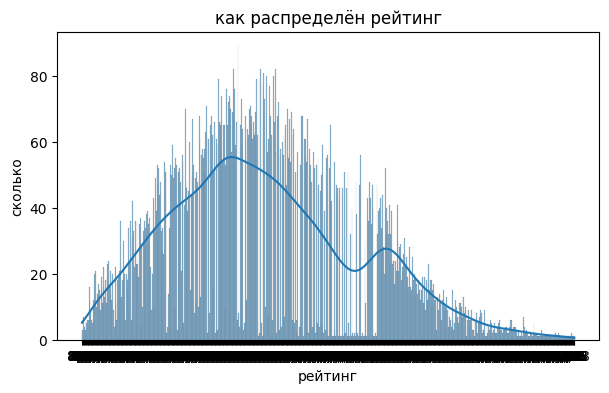

count     15257
unique      610
top        6,50
freq         89
Name: Rating Average, dtype: object


In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(train['Rating Average'], bins=40, kde=True)
plt.title('как распределён рейтинг')
plt.xlabel('рейтинг')
plt.ylabel('сколько')
plt.show()

print(train['Rating Average'].describe())


числовые: Year Published, Min Players, Max Players, Play Tim, Min Age, Users Rated, BGG Rank, Complexity Average, Owned Users
текстовые: Name, Mechanics, Domains

числа — медиана на пропуски + StandardScaler, текст — TF-IDF

In [8]:
TARGET = 'Rating Average'
ID_COL = 'ID'

numeric_features = [
    'Year Published', 'Min Players', 'Max Players', 'Play Time',
    'Min Age', 'Users Rated', 'BGG Rank', 'Complexity Average', 'Owned Users'
]

text_features = ['Name', 'Mechanics', 'Domains']

# в ксв рейтинги/числа иногда с запятой как строка
for col in numeric_features + [TARGET]:
    train[col] = pd.to_numeric(
        train[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

for col in numeric_features:
    test[col] = pd.to_numeric(
        test[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

x = train[numeric_features + text_features].copy()
y = train[TARGET].copy()
x_test = test[numeric_features + text_features].copy()

# nan в тексте на пустую строку
for col in text_features:
    x[col] = x[col].fillna('')
    x_test[col] = x_test[col].fillna('')

In [9]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('name_tfidf', TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=2), 'Name'),
        ('mechanics_tfidf', TfidfVectorizer(max_features=1200, token_pattern=r'[^,]+'), 'Mechanics'),
        ('domains_tfidf', TfidfVectorizer(max_features=100, token_pattern=r'[^,]+'), 'Domains'),
    ],
    remainder='drop'
)

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## модели

Ridge на всём (числа+текст)

SGDRegressor аналогично Ridge

RandomForest только на числах

In [11]:
models = {
    'Ridge (num + text)': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'SGDRegressor (num + text)': Pipeline([
        ('prep', preprocessor),
        ('model', SGDRegressor(
            loss='squared_error',
            penalty='l2',
            alpha=1e-4,
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),
    'RandomForest (num only)': Pipeline([
        ('prep', ColumnTransformer([
            ('num', numeric_transformer, numeric_features)
        ])),
        ('model', RandomForestRegressor(
            n_estimators=350,
            max_depth=None,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

scores = {}
for name, model in models.items():
    cv_scores = cross_val_score(
        model,
        x,
        y,
        cv=cv,
        scoring=rmse_scorer,
        n_jobs=1
    )
    rmse_values = -cv_scores
    scores[name] = (rmse_values.mean(), rmse_values.std())
    print(f'{name:30s} -- RMSE: {rmse_values.mean():.5f} ± {rmse_values.std():.5f}')

best_model_name = min(scores, key=lambda k: scores[k][0])
print('по cv меньше всего ошибка у:', best_model_name)

Ridge (num + text)             -- RMSE: 0.55431 ± 0.00929
SGDRegressor (num + text)      -- RMSE: 0.86964 ± 0.02753
RandomForest (num only)        -- RMSE: 0.24048 ± 0.01189
по cv меньше всего ошибка у: RandomForest (num only)


In [12]:
results_df = pd.DataFrame([
    {
        'model': name,
        'cv_rmse_mean': vals[0],
        'cv_rmse_std': vals[1]
    }
    for name, vals in scores.items()
]).sort_values('cv_rmse_mean')

results_df

,model,cv_rmse_mean,cv_rmse_std
2,RandomForest (num only),0.240476,0.011893
0,Ridge (num + text),0.554306,0.009288
1,SGDRegressor (num + text),0.869638,0.027530


## Обучение и предикт

In [13]:
best_model = models[best_model_name]
best_model.fit(x, y)

test_preds = best_model.predict(x_test)

# клип чтобы не вылезти за диапозон
test_preds = np.clip(test_preds, 1, 10)

submission = pd.DataFrame({
    'index': np.arange(len(test), dtype=int),
    'Rating Average': test_preds
})

submission.head()

,index,Rating Average
0,0,8.045429
1,1,7.964886
2,2,8.115429
3,3,8.276686
4,4,8.048000


In [14]:
submission.to_csv('submission.csv', index=False)
print('строк:', len(submission))

строк: 5086


## Вывод

Сравнены модели по RMSE (KFold, 5 сплитов)

Наименьший средний RMSE на валидации у варианта RandomForest (цифрами онли) — RandomForestRegressor только на числовых признаках (текст не подавался в модель).